In [40]:
import pandas as pd
import glob
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score
######Here we will look at some ways of modelling tennis matches. Monte-Carlo simulation, Logistic regression, Markov chain based
# on ELO scores, and Logistic regression (based on several features) + Markov chain
# -----------------------------
# Step 1: Load CSVs
# -----------------------------
folder = '/Users/lukepiper/Documents/Tennis CSVs'
def load_data(folder):
    df = pd.concat(
        (pd.read_csv(f) for f in glob.glob(os.path.join(folder, '*.csv'))),
        ignore_index=True
    )
    df['tourney_date'] = pd.to_datetime(df['tourney_date'], format='%Y%m%d', errors='coerce')
    return df.sort_values('tourney_date')


In [ ]:
### Logistic regression with player aggregate player stats (add time decay like Dixon-Coles???????) ######

In [124]:
df = load_data(folder)
list(df.columns)

['tourney_id',
 'tourney_name',
 'surface',
 'draw_size',
 'tourney_level',
 'tourney_date',
 'match_num',
 'winner_id',
 'winner_seed',
 'winner_entry',
 'winner_name',
 'winner_hand',
 'winner_ht',
 'winner_ioc',
 'winner_age',
 'loser_id',
 'loser_seed',
 'loser_entry',
 'loser_name',
 'loser_hand',
 'loser_ht',
 'loser_ioc',
 'loser_age',
 'score',
 'best_of',
 'round',
 'minutes',
 'w_ace',
 'w_df',
 'w_svpt',
 'w_1stIn',
 'w_1stWon',
 'w_2ndWon',
 'w_SvGms',
 'w_bpSaved',
 'w_bpFaced',
 'l_ace',
 'l_df',
 'l_svpt',
 'l_1stIn',
 'l_1stWon',
 'l_2ndWon',
 'l_SvGms',
 'l_bpSaved',
 'l_bpFaced',
 'winner_rank',
 'winner_rank_points',
 'loser_rank',
 'loser_rank_points']

In [42]:
# -----------------------------
# Step 2: Compute player-level stats
# -----------------------------
def compute_player_stats(df):
    players = []

    # Winner stats
    w_cols = ['winner_name','w_ace','w_df','w_1stIn','w_1stWon','w_2ndWon','w_svpt','w_SvGms']
    w_df = df[w_cols].copy()
    w_df.rename(columns={'winner_name':'player',
                         'w_ace':'ace','w_df':'df',
                         'w_1stIn':'first_in','w_1stWon':'first_won',
                         'w_2ndWon':'second_won','w_svpt':'total_serves',
                         'w_SvGms':'service_games'}, inplace=True)
    w_df['role'] = 'winner'

    # Loser stats
    l_cols = ['loser_name','l_ace','l_df','l_1stIn','l_1stWon','l_2ndWon','l_svpt','l_SvGms']
    l_df = df[l_cols].copy()
    l_df.rename(columns={'loser_name':'player',
                         'l_ace':'ace','l_df':'df',
                         'l_1stIn':'first_in','l_1stWon':'first_won',
                         'l_2ndWon':'second_won','l_svpt':'total_serves',
                         'l_SvGms':'service_games'}, inplace=True)
    l_df['role'] = 'loser'

    # Combine
    all_players = pd.concat([w_df, l_df], ignore_index=True)

    # Aggregate per player
    player_stats = all_players.groupby('player').agg(
        total_matches=('total_serves','count'),
        ace_rate=('ace','sum'),
        df_rate=('df','sum'),
        first_in_total=('first_in','sum'),
        first_won_total=('first_won','sum'),
        second_won_total=('second_won','sum'),
        total_serves=('total_serves','sum'),
        service_games=('service_games','sum')
    )

    # Compute percentages
    player_stats['ace_pct'] = player_stats['ace_rate'] / player_stats['total_serves']
    player_stats['df_pct'] = player_stats['df_rate'] / player_stats['total_serves']
    player_stats['first_in_pct'] = player_stats['first_in_total'] / player_stats['total_serves']
    player_stats['first_won_pct'] = player_stats['first_won_total'] / player_stats['first_in_total']
    player_stats['second_won_pct'] = player_stats['second_won_total'] / (player_stats['total_serves'] - player_stats['first_in_total'])
    player_stats.fillna(0, inplace=True)

    return player_stats

In [44]:
# -----------------------------
# Step 3: Build match-level dataset
# -----------------------------
def build_match_features(df, player_stats):
    features = []
    for _, row in df.iterrows():
        winner = row['winner_name']
        loser = row['loser_name']

        if winner not in player_stats.index or loser not in player_stats.index:
            continue  # skip if stats missing

        # Feature differences (winner - loser)
        feat = {}
        for col in ['ace_pct','df_pct','first_in_pct','first_won_pct','second_won_pct']:
            feat[f'{col}_diff'] = player_stats.loc[winner,col] - player_stats.loc[loser,col]

        feat['winner'] = 1  # target
        features.append(feat)

        # Also add the reverse for balance (loser perspective)
        rev_feat = {k.replace('_diff','_diff'): -v for k,v in feat.items() if k != 'winner'}
        rev_feat['winner'] = 0
        features.append(rev_feat)

    feature_df = pd.DataFrame(features)
    feature_df.dropna(inplace=True)
    return feature_df



In [46]:
# -----------------------------
# Step 4: Train baseline model
# -----------------------------
def train_baseline_model(feature_df):
    X = feature_df.drop(columns=['winner'])
    y = feature_df['winner']

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    model = LogisticRegression()
    model.fit(X_train_scaled, y_train)

    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:,1]

    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("ROC AUC:", roc_auc_score(y_test, y_proba))
    return model, scaler

In [50]:
# -----------------------------
# Step 5: Run everything
# -----------------------------
folder_path = '/Users/lukepiper/Documents/Tennis CSVs'  # <-- change to your folder path
df_matches = load_data(folder_path)
player_stats = compute_player_stats(df_matches)
match_features = build_match_features(df_matches, player_stats)
model, scaler = train_baseline_model(match_features)


Accuracy: 0.6234203340318791
ROC AUC: 0.6783978889372153


In [54]:
def get_point_win_prob(player, opponent, player_stats):
    
    #Estimate probability player wins a point on serve against opponent.

    p_first_in = player_stats.loc[player,'first_in_pct']
    p_ace = player_stats.loc[player,'ace_pct']
    p_first_won = player_stats.loc[player,'first_won_pct']
    p_second_won = player_stats.loc[player,'second_won_pct']
    
    # Effective point win probability on serve
    p_point = p_ace + (1 - p_ace) * (p_first_in * p_first_won + (1 - p_first_in) * p_second_won)
    return min(max(p_point,0),1)  # ensure 0<=p<=1

In [56]:
import numpy as np

def simulate_game(server, receiver, player_stats):
    p = get_point_win_prob(server, receiver, player_stats)
    server_points = 0
    receiver_points = 0
    while True:
        if np.random.rand() < p:
            server_points += 1
        else:
            receiver_points += 1
        # win by 2 and at least 4 points
        if server_points >= 4 and server_points - receiver_points >= 2:
            return server
        elif receiver_points >= 4 and receiver_points - server_points >= 2:
            return receiver

In [58]:
def simulate_set(server, receiver, player_stats):
    server_games = 0
    receiver_games = 0
    current_server = server
    current_receiver = receiver
    while True:
        winner = simulate_game(current_server, current_receiver, player_stats)
        if winner == current_server:
            server_games += 1
        else:
            receiver_games += 1
        # alternate server
        current_server, current_receiver = current_receiver, current_server
        if server_games >= 6 and server_games - receiver_games >= 2:
            return server
        elif receiver_games >= 6 and receiver_games - server_games >= 2:
            return receiver

In [60]:
def simulate_match(playerA, playerB, player_stats, n_simulations=1000):
    wins_A = 0
    for _ in range(n_simulations):
        sets_won_A = 0
        sets_won_B = 0
        # simulate sets
        for _ in range(3):  # max 3 sets
            set_winner = simulate_set(playerA, playerB, player_stats)
            if set_winner == playerA:
                sets_won_A += 1
            else:
                sets_won_B += 1
            if sets_won_A == 2 or sets_won_B == 2:
                break
        if sets_won_A > sets_won_B:
            wins_A += 1
    return wins_A / n_simulations  # probability playerA wins

In [66]:
playerA = "Tomas Machac"
playerB = "Aleksandar Kovacevic"
mc_prob = simulate_match(playerA, playerB, player_stats)
print(f"Monte Carlo simulated probability Player A wins: {mc_prob:.2f}")

# Logistic regression probability
# Construct feature differences
diff_feat = {}
for col in ['ace_pct','df_pct','first_in_pct','first_won_pct','second_won_pct']:
    diff_feat[f'{col}_diff'] = player_stats.loc[playerA,col] - player_stats.loc[playerB,col]

# Wrap the features in a DataFrame with the same columns as training
X_sim = pd.DataFrame([diff_feat])  
X_sim_scaled = scaler.transform(X_sim)
lr_prob = model.predict_proba(X_sim_scaled)[0,1]
print(f"Logistic regression predicted probability Player A wins: {lr_prob:.2f}")

Monte Carlo simulated probability Player A wins: 1.00
Logistic regression predicted probability Player A wins: 0.62


In [68]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, log_loss, brier_score_loss

# -----------------------------
# Step 0: Assume player_stats and match_features already exist
# match_features = build_match_features(...)
# player_stats = compute_player_stats(...)
# -----------------------------

# -----------------------------
# Step 1: Train-test split
# -----------------------------
X = match_features.drop(columns=['winner'])
y = match_features['winner']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# -----------------------------
# Step 2: Train Logistic Regression
# -----------------------------
lr_model = LogisticRegression()
lr_model.fit(X_train_scaled, y_train)

# LR predictions
y_pred_lr = lr_model.predict(X_test_scaled)
y_proba_lr = lr_model.predict_proba(X_test_scaled)[:,1]

# -----------------------------
# Step 3: Monte Carlo Simulation Functions
# -----------------------------
def get_point_win_prob(player, opponent, player_stats):
    p_first_in = player_stats.loc[player,'first_in_pct']
    p_ace = player_stats.loc[player,'ace_pct']
    p_first_won = player_stats.loc[player,'first_won_pct']
    p_second_won = player_stats.loc[player,'second_won_pct']
    # probability player wins point on serve
    p_point = p_ace + (1 - p_ace) * (p_first_in * p_first_won + (1 - p_first_in) * p_second_won)
    return min(max(p_point,0),1)

def simulate_game(server, receiver, player_stats):
    p = get_point_win_prob(server, receiver, player_stats)
    s_points = 0
    r_points = 0
    while True:
        if np.random.rand() < p:
            s_points += 1
        else:
            r_points += 1
        if s_points >= 4 and s_points - r_points >= 2:
            return server
        elif r_points >= 4 and r_points - s_points >= 2:
            return receiver

def simulate_set(server, receiver, player_stats):
    s_games = 0
    r_games = 0
    current_server = server
    current_receiver = receiver
    while True:
        winner = simulate_game(current_server, current_receiver, player_stats)
        if winner == current_server:
            s_games += 1
        else:
            r_games += 1
        current_server, current_receiver = current_receiver, current_server
        if s_games >= 6 and s_games - r_games >= 2:
            return server
        elif r_games >= 6 and r_games - s_games >= 2:
            return receiver

def simulate_match(playerA, playerB, player_stats, n_simulations=100):
    wins_A = 0
    for _ in range(n_simulations):
        sets_won_A = 0
        sets_won_B = 0
        for _ in range(3):
            set_winner = simulate_set(playerA, playerB, player_stats)
            if set_winner == playerA:
                sets_won_A += 1
            else:
                sets_won_B += 1
            if sets_won_A == 2 or sets_won_B == 2:
                break
        if sets_won_A > sets_won_B:
            wins_A += 1
    return wins_A / n_simulations

# -----------------------------
# Step 4: Monte Carlo predictions on test set
# -----------------------------
mc_probs = []
for idx in X_test.index:
    winner_name = X_test.loc[idx].name if 'winner_name' in X_test.columns else None
    loser_name = X_test.loc[idx].name if 'loser_name' in X_test.columns else None
    # fallback: we have to map idx to original df_matches to get names
    row = match_features.iloc[idx]
    # You need original names; assuming match_features has a mapping to original df
    # For baseline, let's just simulate using the same columns as keys
    # Example: simulate using winner as Player A, loser as Player B
    try:
        playerA = df_matches.iloc[idx]['winner_name']
        playerB = df_matches.iloc[idx]['loser_name']
        probA = simulate_match(playerA, playerB, player_stats, n_simulations=100)
        mc_probs.append(probA)
    except:
        mc_probs.append(0.5)  # fallback if stats missing

y_proba_mc = np.array(mc_probs)
y_pred_mc = (y_proba_mc >= 0.5).astype(int)

# -----------------------------
# Step 5: Evaluation
# -----------------------------
def evaluate_model(y_true, y_pred, y_proba, model_name):
    print(f"\n=== {model_name} Evaluation ===")
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("ROC AUC:", roc_auc_score(y_true, y_proba))
    print("Log Loss:", log_loss(y_true, y_proba))
    print("Brier Score:", brier_score_loss(y_true, y_proba))

# Logistic Regression
evaluate_model(y_test, y_pred_lr, y_proba_lr, "Logistic Regression")

# Monte Carlo
evaluate_model(y_test, y_pred_mc, y_proba_mc, "Monte Carlo Simulation")


=== Logistic Regression Evaluation ===
Accuracy: 0.6234203340318791
ROC AUC: 0.6783978889372153
Log Loss: 0.633781297802957
Brier Score: 0.22341580591690194

=== Monte Carlo Simulation Evaluation ===
Accuracy: 0.5046040515653776
ROC AUC: 0.502266235320841
Log Loss: 8.24835130540999
Brier Score: 0.3687689909189052


In [178]:
## Extremely inefficient monte carlo simulation with elo, try purely markov model with ELO probs????

import pandas as pd
import numpy as np

# -----------------------------
# Step 0: Prepare training and test data
# -----------------------------
from sklearn.model_selection import train_test_split

df_train, df_test = train_test_split(df_matches, test_size=0.2, random_state=42, shuffle=True)

# -----------------------------
# Step 1: Generate Elo from training data only
# -----------------------------
def generate_elo(df_matches, initial_elo=1500, k=32):
    elo_dict = {}
    for _, row in df_matches.iterrows():
        winner = row['winner_name']
        loser = row['loser_name']
        if winner not in elo_dict:
            elo_dict[winner] = initial_elo
        if loser not in elo_dict:
            elo_dict[loser] = initial_elo
        Rw = elo_dict[winner]
        Rl = elo_dict[loser]
        Ew = 1 / (1 + 10 ** ((Rl - Rw)/400))
        El = 1 - Ew
        elo_dict[winner] += k * (1 - Ew)
        elo_dict[loser] += k * (0 - El)
    return elo_dict

elo_dict_train = generate_elo(df_train)

# -----------------------------
# Step 2: Monte Carlo Functions
# -----------------------------
# Basic Elo-based win probability
def elo_win_prob(playerA, playerB, elo_dict):
    Ra = elo_dict.get(playerA, 1500)
    Rb = elo_dict.get(playerB, 1500)
    return 1 / (1 + 10 ** ((Rb - Ra)/400))

# Point probability including ace chance
def get_point_prob_elo(server, receiver, elo_dict, player_stats):
    p_match = elo_win_prob(server, receiver, elo_dict)
    p_ace = player_stats.loc[server,'ace_pct'] if server in player_stats.index else 0.05
    return min(p_match**(1/4) + p_ace, 0.99)

def simulate_game_elo(server, receiver, elo_dict, player_stats):
    s_points, r_points = 0, 0
    p = get_point_prob_elo(server, receiver, elo_dict, player_stats)
    while True:
        if np.random.rand() < p:
            s_points += 1
        else:
            r_points += 1
        if s_points >= 4 and s_points - r_points >= 2:
            return server
        elif r_points >= 4 and r_points - s_points >= 2:
            return receiver

def simulate_set_elo(playerA, playerB, elo_dict, player_stats):
    gamesA, gamesB = 0, 0
    server, receiver = playerA, playerB
    while True:
        winner = simulate_game_elo(server, receiver, elo_dict, player_stats)
        if winner == playerA:
            gamesA += 1
        else:
            gamesB += 1
        server, receiver = receiver, server  # alternate serve
        if (gamesA >= 6 or gamesB >= 6) and abs(gamesA - gamesB) >= 2:
            return playerA if gamesA > gamesB else playerB

def simulate_match_elo(playerA, playerB, elo_dict, player_stats, n_simulations=50):
    wins_A = 0
    for _ in range(n_simulations):
        sets_won_A, sets_won_B = 0, 0
        for _ in range(3):  # best of 3 sets
            set_winner = simulate_set_elo(playerA, playerB, elo_dict, player_stats)
            if set_winner == playerA:
                sets_won_A += 1
            else:
                sets_won_B += 1
            if sets_won_A == 2 or sets_won_B == 2:
                break
        if sets_won_A > sets_won_B:
            wins_A += 1
    return wins_A / n_simulations

# -----------------------------
# Step 3: Predict matches on test set
# -----------------------------
y_pred_mc_prob = []
for _, row in df_test.iterrows():
    playerA = row['winner_name']
    playerB = row['loser_name']
    prob = simulate_match_elo(playerA, playerB, elo_dict_train, player_stats, n_simulations=50)
    y_pred_mc_prob.append(prob)

y_pred_mc_prob = np.array(y_pred_mc_prob)

# -----------------------------
# Step 4: Evaluate
# -----------------------------
from sklearn.metrics import accuracy_score, roc_auc_score, log_loss, brier_score_loss

# y_true = 1 for actual winner, 0 if you want to invert
y_true = np.ones(len(df_test))  # simple baseline

acc = accuracy_score(y_true, (y_pred_mc_prob>0.5).astype(int))
roc = roc_auc_score(y_true, y_pred_mc_prob)
ll = log_loss(y_true, y_pred_mc_prob)
brier = brier_score_loss(y_true, y_pred_mc_prob)

print("=== Monte Carlo (Elo+Ace) Evaluation ===")
print(f"Accuracy: {acc}")
print(f"ROC AUC: {roc}")
print(f"Log Loss: {ll}")
print(f"Brier Score: {brier}")

KeyboardInterrupt: 

In [104]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, log_loss, brier_score_loss

# -----------------------------
# Step 1: Train/Test Split
# -----------------------------
df_train, df_test = train_test_split(df_matches, test_size=0.2, random_state=42, shuffle=True)

# -----------------------------
# Step 2: Generate Elo (TRAIN ONLY)
# -----------------------------
def generate_elo(df_matches, initial_elo=1500, k=32):
    elo = {}
    for _, row in df_matches.iterrows():
        w, l = row['winner_name'], row['loser_name']
        
        if w not in elo: elo[w] = initial_elo
        if l not in elo: elo[l] = initial_elo
        
        Rw, Rl = elo[w], elo[l]
        Ew = 1 / (1 + 10 ** ((Rl - Rw)/400))
        
        elo[w] += k * (1 - Ew)
        elo[l] += k * (0 - (1 - Ew))
        
    return elo

elo_dict = generate_elo(df_train)

# -----------------------------
# Step 3: Point Probability (Elo + Ace)
# -----------------------------
def elo_win_prob(a, b):
    Ra = elo_dict.get(a, 1500)
    Rb = elo_dict.get(b, 1500)
    return 1 / (1 + 10 ** ((Rb - Ra)/400))

def point_prob(server, receiver):
    p_match = elo_win_prob(server, receiver)
    p_ace = player_stats.loc[server,'ace_pct'] if server in player_stats.index else 0.05
    return min(p_match**(1/4) + p_ace, 0.99)

# -----------------------------
# Step 4: Game Win Probability
# -----------------------------
def game_win_prob(p):
    q = 1 - p
    
    pre_deuce = p**4 * (1 + 4*q + 10*q**2)
    deuce = 20 * (p**3) * (q**3)
    deuce_win = (p**2) / (1 - 2*p*q)
    
    return pre_deuce + deuce * deuce_win

# -----------------------------
# Step 5: Set Win Probability (Markov)
# -----------------------------
from functools import lru_cache

@lru_cache(None)
def set_win_prob(a_games, b_games, server_turn, gA, gB):
    # win conditions
    if a_games >= 6 and a_games - b_games >= 2:
        return 1
    if b_games >= 6 and b_games - a_games >= 2:
        return 0
    
    # simple tiebreak approximation
    if a_games == 6 and b_games == 6:
        return 0.5
    
    # who is serving
    if server_turn == 0:
        p = gA
    else:
        p = 1 - gB
    
    win = set_win_prob(a_games+1, b_games, 1-server_turn, gA, gB)
    lose = set_win_prob(a_games, b_games+1, 1-server_turn, gA, gB)
    
    return p * win + (1 - p) * lose

# -----------------------------
# Step 6: Match Probability
# -----------------------------
def match_win_prob(set_p):
    return set_p**2 * (3 - 2*set_p)  # best of 3

def predict_match(playerA, playerB):
    pA = point_prob(playerA, playerB)
    pB = point_prob(playerB, playerA)
    
    gA = game_win_prob(pA)
    gB = game_win_prob(pB)
    
    set_p = set_win_prob(0, 0, 0, gA, gB)
    
    return match_win_prob(set_p)

# -----------------------------
# Step 7: Predict on Test Set
# -----------------------------
y_true = []
y_pred = []

for _, row in df_test.iterrows():
    A = row['winner_name']
    B = row['loser_name']
    
    # A vs B (A wins)
    prob_A = predict_match(A, B)
    y_true.append(1)
    y_pred.append(prob_A)
    
    # B vs A (B loses)
    prob_B = predict_match(B, A)
    y_true.append(0)
    y_pred.append(prob_B)

import numpy as np

y_true = np.array(y_true)
y_pred = np.array(y_pred)
# -----------------------------
# Step 8: Evaluation
# -----------------------------
print("=== Markov Model Evaluation ===")
print("Accuracy:", accuracy_score(y_true, (y_pred > 0.5)))
print("ROC AUC:", roc_auc_score(y_true, y_pred))
print("Log Loss:", log_loss(y_true, y_pred))
print("Brier Score:", brier_score_loss(y_true, y_pred))

=== Markov Model Evaluation ===
Accuracy: 0.6049022098044196
ROC AUC: 0.6509488825429264
Log Loss: 0.6607259038993712
Brier Score: 0.2339529170682452


In [156]:
df_train, df_test = train_test_split(df_matches, test_size=0.2, random_state=42, shuffle=True)
## Get elo on train set 
def generate_elo(df, initial_elo=1500, k=32):
    elo = {}
    
    for _, row in df.iterrows():
        w, l = row['winner_name'], row['loser_name']
        
        if w not in elo: elo[w] = initial_elo
        if l not in elo: elo[l] = initial_elo
        
        Rw, Rl = elo[w], elo[l]
        Ew = 1 / (1 + 10 ** ((Rl - Rw)/400))
        
        elo[w] += k * (1 - Ew)
        elo[l] += k * (0 - (1 - Ew))
    
    return elo

elo_dict = generate_elo(df_train)


In [158]:
## Match dataset for Just ML 
def build_match_dataset(df):
    rows = []
    
    for _, row in df.iterrows():
        A, B = row['winner_name'], row['loser_name']
        Ra = elo_dict.get(A, 1500)
        Rb = elo_dict.get(B, 1500)
        
        rows.append({'elo_diff': Ra - Rb, 'surface': row['surface'], 'target': 1})
        rows.append({'elo_diff': Rb - Ra, 'surface': row['surface'], 'target': 0})
    
    return pd.DataFrame(rows)

match_train = build_match_dataset(df_train)

In [160]:
## From serve stats
def build_point_dataset(df):
    rows = []
    
    for _, row in df.iterrows():
        A = row['winner_name']
        B = row['loser_name']
        
        Ra = elo_dict.get(A, 1500)
        Rb = elo_dict.get(B, 1500)
        
        if row['w_svpt'] > 0 and row['l_svpt'] > 0:
            
            # Winner serving
            p_w = (row['w_1stWon'] + row['w_2ndWon']) / row['w_svpt']
            
            rows.append({
                'elo_diff': Ra - Rb,
                'surface': row['surface'],
                'server': 1,   # serving advantage
                'target': p_w
            })
            
            # Loser serving
            p_l = (row['l_1stWon'] + row['l_2ndWon']) / row['l_svpt']
            
            rows.append({
                'elo_diff': Rb - Ra,
                'surface': row['surface'],
                'server': 1,
                'target': p_l
            })
    
    return pd.DataFrame(rows)

point_train = build_point_dataset(df_train)

In [162]:
#Train match ML 
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression

preprocess = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), ['surface'])
], remainder='passthrough')

match_model = Pipeline([
    ('prep', preprocess),
    ('clf', LogisticRegression(max_iter=1000))
])

X_match = match_train[['elo_diff','surface']]
y_match = match_train['target']

match_model.fit(X_match, y_match)

/opt/anaconda3/lib/python3.12/site-packages/sklearn/compose/_column_transformer.py:1623: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('prep',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['surface'])])),
                ('clf', LogisticRegression(max_iter=1000))])

In [164]:
# Train point ML 
from sklearn.ensemble import HistGradientBoostingRegressor

point_model = Pipeline([
    ('prep', preprocess),
    ('reg', HistGradientBoostingRegressor())
])

X_point = point_train[['elo_diff','surface']]
y_point = point_train['target']

point_model.fit(X_point, y_point)

/opt/anaconda3/lib/python3.12/site-packages/sklearn/compose/_column_transformer.py:1623: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('prep',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['surface'])])),
                ('reg', HistGradientBoostingRegressor())])

In [168]:
def predict_ml(A, B, surface):
    Ra = elo_dict.get(A, 1500)
    Rb = elo_dict.get(B, 1500)
    
    X = pd.DataFrame([{
        'elo_diff': Ra - Rb,
        'surface': surface
    }])
    
    return match_model.predict_proba(X)[0,1]

def point_prob_ml(server, receiver, surface):
    Ra = elo_dict.get(server, 1500)
    Rb = elo_dict.get(receiver, 1500)
    
    X = pd.DataFrame([{
        'elo_diff': Ra - Rb,
        'surface': surface
    }])
    
    p = point_model.predict(X)[0]
    
    return np.clip(p, 0.01, 0.99)

In [170]:
def predict_markov(A, B, surface):
    pA = point_prob_ml(A, B, surface)
    pB = point_prob_ml(B, A, surface)
    
    gA = game_win_prob(pA)
    gB = game_win_prob(pB)
    
    set_p = set_win_prob(0, 0, 0, gA, gB)
    
    return match_win_prob(set_p)

In [172]:
y_true = []
y_pred_ml = []
y_pred_markov = []

for _, row in df_test.iterrows():
    A = row['winner_name']
    B = row['loser_name']
    surface = row['surface']
    
    # forward
    y_true.append(1)
    y_pred_ml.append(predict_ml(A,B,surface))
    y_pred_markov.append(predict_markov(A,B,surface))
    
    # reverse
    y_true.append(0)
    y_pred_ml.append(predict_ml(B,A,surface))
    y_pred_markov.append(predict_markov(B,A,surface))

y_true = np.array(y_true)
y_pred_ml = np.array(y_pred_ml)
y_pred_markov = np.array(y_pred_markov)

In [174]:
def evaluate(name, y_true, y_pred):
    print(f"\n=== {name} ===")
    print("Accuracy:", accuracy_score(y_true, y_pred > 0.5))
    print("ROC AUC:", roc_auc_score(y_true, y_pred))
    print("Log Loss:", log_loss(y_true, y_pred))
    print("Brier Score:", brier_score_loss(y_true, y_pred))

evaluate("ML", y_true, y_pred_ml)
evaluate("ML + Markov (corrected)", y_true, y_pred_markov)


=== ML ===
Accuracy: 0.6041402082804166
ROC AUC: 0.6512415766767018
Log Loss: 0.6599851283389795
Brier Score: 0.23367836192672858

=== ML + Markov (corrected) ===
Accuracy: 0.603505207010414
ROC AUC: 0.6508388984519905
Log Loss: 0.680217881719889
Brier Score: 0.24108452077176137


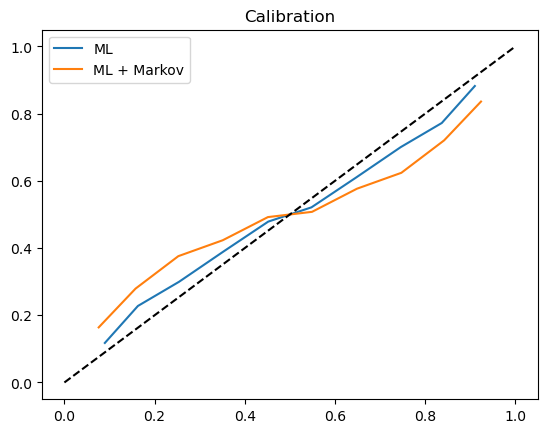

In [176]:
p_true_ml, p_pred_ml = calibration_curve(y_true, y_pred_ml, n_bins=10)
p_true_mk, p_pred_mk = calibration_curve(y_true, y_pred_markov, n_bins=10)

plt.plot(p_pred_ml, p_true_ml, label="ML")
plt.plot(p_pred_mk, p_true_mk, label="ML + Markov")
plt.plot([0,1],[0,1],'k--')
plt.legend()
plt.title("Calibration")
plt.show()

In [ ]:
### At what point does using Markov mchain model improve results???? #### 
### Use in play data + Markov approach, then compare to live odds to dentify opportunities?? ###

In [195]:
max(elo_dict)
max(elo_dict, key=elo_dict.get)

'David Goffin'

In [197]:
elo_dict['David Goffin']

1832.4132111192405